# 🔥 FireGuard — Full Pipeline

From raw dataset to deployment-ready model, **in one notebook**.
Domain: **indoor CCTV camera** (home · office · shop). Two classes: `fire` and `smoke`.

---

## Section map

**Always just hit `Run all`.** The pipeline is managed: every heavy section leaves a "mark"
on the drive; the next run sees it and **skips itself**. After a Colab disconnect, the same
`Run all` — a few minutes later it goes straight to continuing training.

| # | Section | First time | After disconnect | Time |
|---|---|---|---|---|
| 1 | Install + hardware detection | ✅ | ✅ (required) | 2 min |
| 2 | **Settings** ← the only cell you touch | ✅ | ✅ | — |
| 2.5 | ⚡ Fast path — load dataset from Drive | — | ✅ 1-2 min | |
| 3 | Parallel dataset download | ✅ 5-15 min | ⏭️ skipped | |
| 4 | Merge · fix classes · dedup · split | ✅ 10 min | ⏭️ skipped | |
| 5 | Data inspection | ✅ 1 min | ⏭️ skipped | |
| 6 | Build augmentation + `train_args` | ✅ | ✅ (instant) | — |
| 7 | 🚁 Smoke test | ✅ 2 min | ⏭️ skipped (mark) | |
| 8 | Baseline — raw model | ✅ 1 min | ⏭️ skipped (mark) | |
| 9 | 🔬 A/B test (optional, `RUN_ABLATION`) | — | — | 40 min |
| **10** | **Main training** — directly at 640, 60 epochs, early stopping | ✅ | ▶️ **resume from checkpoint** | 8-12 hours |
| 11-14 | Evaluation · operating point · export · model card | after training | | 20 min |

**All "first time" cells are skipped with `if/else` — no error is printed, just a ⏭️ message.**

To force a rerun: `FORCE_REBUILD_DATA=True` (data) or `REDO_CHECKS=True` (sections 7 and 8).

---

## About "only 2 classes"

The base model (`yolo26s.pt`) was trained on COCO with 80 classes. When we train it on
`fire.yaml` with `nc: 2`, Ultralytics **discards the 80-class head and builds a 2-class
head** — you'll see this in the log:

```
Overriding model.yaml nc=80 with nc=2
```

Those 80 classes are only used for the backbone's initial weights (edges, texture, color
gradients — which are the same for a cat and a flame). **The final model has only `fire`
and `smoke`.**

---

## ⚠️ Traps this notebook has already solved

| # | Trap | Solution |
|---|---|---|
| 1 | **Reversed class mapping** — FASDD `0=fire` but D-Fire `0=smoke` | D-Fire labels are swapped with `1-c` |
| 2 | **Consecutive frames** — the AoF section is frames from a video (80-90% similar) | Group-aware split |
| 3 | **Co-event frames were slipping past dedup** — 6-13 bit distance, further out than the removal threshold (3) | Second threshold: 4..12 = "co-event" → locked into one split |
| 4 | **Giant hash buckets** — 39k trivial negatives get the same hash and were being skipped by dedup | An exact-hash O(n) step before the near-duplicate search |
| 5 | **`imgsz>640` is pointless** — FASDD images themselves top out at 640 pixels | Cap of 640 |
| 6 | **`resume` overwrites all arguments from the checkpoint** (`self.args = get_cfg(ckpt_args)`) | Each resolution stage is a fresh `train()`, not a resume |
| 7 | **Drive is slow with lots of small files** | Data and weights on `/content`; sync happens in a background thread |

## 1 · Install and automatic hardware detection

Colab gives you a different machine every time (2 to 8 cores, T4 or L4 or A100).
Instead of a fixed number, `workers` and `batch` are computed from that machine.

In [ ]:
# ═══ core packages ═══
!pip install -q --upgrade ultralytics

# ═══ augmentation ═══
!pip install -q albumentations

# ═══ evaluation and plotting ═══
!pip install -q "matplotlib>=3.8" pandas seaborn

# ═══ production export ═══
!pip install -q onnx onnxslim onnxruntime-gpu

import os, torch, ultralytics
print('ultralytics :', ultralytics.__version__)
print('torch       :', torch.__version__, '| CUDA:', torch.cuda.is_available())

# ---------- hardware detection ----------
N_CPU = os.cpu_count() or 2
HAS_GPU = torch.cuda.is_available()
GPU_NAME, GPU_GB = 'CPU', 0
if HAS_GPU:
    p = torch.cuda.get_device_properties(0)
    GPU_NAME, GPU_GB = p.name, p.total_memory / 1e9

# workers: Ultralytics' default is 8. On a 2-core Colab machine, 2 workers is too few —
# when one worker is waiting on disk, the other core sits idle and the GPU starves.
# Oversubscribing (2x core count) boosts dataloader throughput at no real cost.
AUTO_WORKERS = max(2, min(8, N_CPU * 2))

print(f'\nCPU  : {N_CPU} هسته        → workers = {AUTO_WORKERS}')
print(f'GPU  : {GPU_NAME}  ({GPU_GB:.1f} GB)')
if not HAS_GPU:
    print('\n⚠️  GPU روشن نیست:  Runtime → Change runtime type → T4 GPU')
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv 2>/dev/null | head -2
!df -h /content | tail -1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 5.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ultralytics : 8.4.146
torch       : 2.11.0+cu128 | CUDA: True

CPU  : 2 هسته        → workers = 4
GPU  : Tesla T4  (15.6 GB)
name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 3 MiB
overlay         113

## 2 · Settings

**The only cell you touch.** Just run the rest.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')# ← in the sign-in window, be sure to pick the right account
import os, glob

# ── check: which Google account got mounted? ──
_mydrive = [d for d in os.listdir('/content/drive/MyDrive') if 'FireGuard' in d]
print('📁 پوشه‌های FireGuard در این Drive:', _mydrive or '⚠️ هیچ‌کدام — شاید اکانتِ اشتباه mount شده!')

# ═════════════════ paths ═════════════════
#  main account: leave this. Second Google account (for rotating GPU quota):
#  in Drive → "Shared with me" → right-click the FireGuard folder → "Add shortcut to Drive" →
#  put it in MyDrive, then change DRIVE_ROOT here to that shortcut's path.
DRIVE_ROOT = '/content/drive/MyDrive'# ← only this line changes for a second account
DRIVE_DATA = f'{DRIVE_ROOT}/FireGuard_Datasets'# dataset zip archives
DRIVE_RUNS = f'{DRIVE_ROOT}/FireGuard_Runs'# ★ weights are saved here

# ═════════════════ model ═════════════════
MODEL  = 'yolo26s.pt'# yolo26n is fastest · yolo26s is balanced (recommended) · yolo26m is more accurate
RUN    = 'fireguard_s_v4'# ★ v4 = image-based split (val>train bug from v3 fixed). v3 was on a broken split — discarded

# ═════════════════ training ═════════════════
#  decision: directly at 640 (final resolution), no warm-up stage. Fewer epochs.
#  fine-tuning from COCO on ~2 classes with ~50k images usually converges in under 50 epochs;
#  patience stops it on its own once val flattens out. You can also stop manually whenever mAP looks good
#  (best.pt is always the best so far).
EPOCHS      = 60
PROGRESSIVE = False# ★ no staged resolution — all epochs at 640
IMGSZ_HI    = 640# final resolution and the only resolution. Don't go higher — FASDD images max out at 640
IMGSZ_LO    = 640# (not used when PROGRESSIVE=False)
STAGE1_FRAC = 0.60
FINISH_STAGE1_NOW = False

PATIENCE = 20# ★ if mAP hasn't improved in 20 epochs, stop automatically
BATCH   = 32# ★ at 640 on a T4: batch=16 only filled ~5G of 15G GPU. 32 ≈ 9-10G and ~15% faster.
                     #    if you see "CUDA out of memory" → 24. if GPU_mem stays under 8G → 40
INIT_WEIGHTS = None# ★ path to warm-start weights. To continue v4 with a new batch:
                     #    'ROOT/FireGuard_Runs/fireguard_s_v4/s2_hi/weights/best.pt'  + change RUN to v5
                     #    (a normal resume locks the batch; this is the way to change batch mid-run)
WORKERS = None# None = automatic (2x core count)
CACHE   = 'disk'# 'disk' = repeated decoding is eliminated. May not fit at 640 → turns off automatically (fine)

# ═════════════════ options ═════════════════
CCTV_AUG    = True# augmentation tailored to CCTV cameras
RUN_SMOKETEST = True# 🚁 smoke test before main training — don't turn this off
RUN_ABLATION  = False# 🔬 A/B test on augmentation (40 min) — section 8
REDO_CHECKS = False# ★ True = rerun sections 5/7/8 even if already completed
IGNORE_LOCK = False# ★ True = ignore the "another session is training" lock (only if you're sure that session is dead)

# ═════════════════ data ═════════════════
USE_FASDD, USE_DFIRE = True, True
DEDUP, DEDUP_DISTANCE, GROUP_DISTANCE = True, 3, 12
SYNC_EVERY = 2# sync weights to Drive every this many epochs (smaller = less lost work on disconnect, busier Drive)
FORCE_REBUILD_DATA = False# ★ True = rebuild the dataset from scratch, even if fireguard_data.zip is on Drive
                             #   (only when you've changed the dataset or dedup settings)
NEG_RATIO = 1.1# ★ max ratio of negative to positive images (the v4 dataset was built with this — don't change it or
                            #   the fingerprint changes, the whole dataset gets rebuilt, and resume breaks).
                            #   note: for ~2x speed you could set 0.6 (smaller train set → cache=disk fits),
                            #   but that means starting a fresh RUN. Keep it at 1.1 to continue v4.

# ══════════════════════════════════════════
WORK      = '/content/work'
DATA_DIR  = '/content/fireguard_data'
RUNS_LOCAL= '/content/runs'
DRIVE_RUN = f'{DRIVE_RUNS}/{RUN}'
YAML      = f'{DATA_DIR}/fire.yaml'
if WORKERS is None: WORKERS = AUTO_WORKERS

DATA_MARKS = f'{DRIVE_DATA}/marks'# marks shared across all RUNs (data-dependent)
RUN_MARKS  = f'{DRIVE_RUN}/marks'# marks specific to this RUN
for d in (DRIVE_DATA, DRIVE_RUNS, DRIVE_RUN, WORK, RUNS_LOCAL, DATA_MARKS, RUN_MARKS):
    os.makedirs(d, exist_ok=True)

# ═══ managed progress system ═══
#  every heavy section leaves a "mark" on Drive. Next run: mark exists → skip, doesn't → run.
#  nothing is lost on a Colab disconnect; only the unfinished work is redone.
import json, time

# data recipe fingerprint — if it changes, the dataset must be rebuilt
DATA_FP = json.dumps({'fasdd': USE_FASDD, 'dfire': USE_DFIRE, 'dedup': DEDUP,
                      'dd': DEDUP_DISTANCE, 'gd': GROUP_DISTANCE, 'neg': NEG_RATIO,
                      'split': 'by_image_v2'}, sort_keys=True)# ← image-based split; previous zips are invalidated
_fp_file = f'{DATA_MARKS}/data_fingerprint.txt'
_fp_old  = open(_fp_file).read() if os.path.exists(_fp_file) else ''
DATA_STALE = (_fp_old != DATA_FP)

if FORCE_REBUILD_DATA or DATA_STALE:
    for _m in ('smoketest.ok',):
        try: os.remove(f'{DATA_MARKS}/{_m}')
        except OSError: pass
    try: os.remove(f'{DRIVE_DATA}/fireguard_data.zip')
    except OSError: pass

def has_mark(name, shared=True):
    return os.path.exists(f'{(DATA_MARKS if shared else RUN_MARKS)}/{name}')
def set_mark(name, shared=True, body=''):
    open(f'{(DATA_MARKS if shared else RUN_MARKS)}/{name}', 'w').write(str(body) or str(time.time()))

print(f'مدل        : {MODEL}')
print(f'اجرا       : {RUN}')
print(f'epochs     : {EPOCHS}' + (f'  (پلکانی: {int(EPOCHS*STAGE1_FRAC)} @{IMGSZ_LO} + {EPOCHS-int(EPOCHS*STAGE1_FRAC)} @{IMGSZ_HI})' if PROGRESSIVE else f'  @{IMGSZ_HI}'))
print(f'batch      : {"AutoBatch" if BATCH==-1 else BATCH}   workers: {WORKERS}   cache: {CACHE}')
print(f'وزن‌ها     → {DRIVE_RUN}')

_data_ok  = (not FORCE_REBUILD_DATA and not DATA_STALE
             and os.path.exists(f'{DRIVE_DATA}/fireguard_data.zip'))
_smoke_ok = has_mark('smoketest.ok') and not REDO_CHECKS
_stages   = json.load(open(f'{DRIVE_RUN}/state.json')).get('done', []) if os.path.exists(f'{DRIVE_RUN}/state.json') else []
print('\n📋 وضعیت (نشانه‌های درایو):')
print(f'   دیتاست آماده      : {"✅ رد می‌شود" if _data_ok else "⬜ ساخته می‌شود (بخش ۳ و ۴)"}')
print(f'   پرواز آزمایشی     : {"✅ رد می‌شود" if _smoke_ok else "⬜ اجرا می‌شود (بخش ۷)"}')
print(f'   مرحله‌های آموزش   : {_stages or "هیچ‌کدام — از ابتدا"}')
if DATA_STALE and _fp_old:
    print('   ⚠️ دستور پختِ داده عوض شده — دیتاست از نو ساخته می‌شود')

Mounted at /content/drive
📁 پوشه‌های FireGuard در این Drive: ['FireGuard_Runs', 'FireGuard_Datasets']
مدل        : yolo26s.pt
اجرا       : fireguard_s_v4
epochs     : 60  @640
batch      : 32   workers: 4   cache: disk
وزن‌ها     → /content/drive/MyDrive/FireGuard_Runs/fireguard_s_v4

📋 وضعیت (نشانه‌های درایو):
   دیتاست آماده      : ✅ رد می‌شود
   پرواز آزمایشی     : ✅ رد می‌شود
   مرحله‌های آموزش   : هیچ‌کدام — از ابتدا


## 2.5 · ⚡ Fast path — skip data preparation

The first time, sections 3 and 4 (download · merge · dedup · split) build the final dataset
and store it as `fireguard_data.zip` on Drive.

**Later sessions** (after a Colab disconnect) this cell just grabs that same file and unpacks it —
about 1 to 2 minutes instead of 15 to 20. If it finds it, sections 3 and 4 **skip themselves**
(each of their cells checks `DATA_READY` first).

If you changed the dataset or the dedup settings, set `FORCE_REBUILD_DATA = True`.

In [ ]:
import os, zipfile, time

DATA_READY = False
_prepared = f'{DRIVE_DATA}/fireguard_data.zip'

if _data_ok and os.path.getsize(_prepared) > 5e6:
    t = time.time()
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(_prepared) as z:
        z.extractall(DATA_DIR)
    if not os.path.exists(YAML):
        with open(YAML, 'w') as f:
            f.write('\n'.join([f'path: {DATA_DIR}', 'train: images/train', 'val: images/val',
                               'test: images/test', '', 'nc: 2', 'names:',
                               '  0: fire', '  1: smoke', '']))
    n = sum(len(fs) for _, _, fs in os.walk(f'{DATA_DIR}/images'))
    ok = n > 1000 and os.path.isdir(f'{DATA_DIR}/images/train')
    if ok:
        DATA_READY = True
        print(f'⚡ دیتاست آماده از درایو باز شد: {n:,} تصویر در {time.time()-t:.0f}s')
        print('   → بخش‌های ۳ و ۴ را رد کن (خودشان هم رد می‌شوند). برو بخش ۵.')
    else:
        print(f'⚠️ زیپ ناقص به‌نظر می‌رسد ({n:,} تصویر) — بخش‌های ۳ و ۴ را کامل اجرا کن')
else:
    why = ('FORCE_REBUILD_DATA=True' if FORCE_REBUILD_DATA else
           'دستور پختِ داده عوض شده' if DATA_STALE else 'fireguard_data.zip در درایو نیست')
    print(f'مسیر سریع فعال نشد ({why}) — بخش‌های ۳ و ۴ کامل اجرا می‌شوند')

⚡ دیتاست آماده از درایو باز شد: 56,261 تصویر در 63s
   → بخش‌های ۳ و ۴ را رد کن (خودشان هم رد می‌شوند). برو بخش ۵.


## 3 · **Parallel** dataset download

> ⚡ If the "fast path" cell said `DATA_READY` — this section and section 4 skip themselves.

FASDD (3.4 GB, one file) and D-Fire (21k small files) are downloaded **simultaneously**.
Since one is bandwidth-bound and the other is request-count-bound, parallelizing them
genuinely saves time — it's not just for show.

The zips stay on Drive and **are not unpacked**; Drive takes hours with 95k small files
and usually breaks partway through.

In [ ]:
# ── this cell only runs the first time; later runs it skips cleanly ──
if DATA_READY:
    print('⏭️  بخش ۳ رد شد — دیتاست از درایو آماده است')
else:
    # ═══════════════════════════════════════════════════════════════════════
    #  robust download — fixed version after the 429 error
    #
    #  what happened: snapshot_download was fetching 14,614 separate files with 16 threads and
    #  sending a token request to HF for each one → HTTP 429 Too Many Requests.
    #  (it wasn't an internet problem.)
    #
    #  fix: the same dataset also has a parquet version — **12 files instead of 14,614**.
    #  the `label` field is exactly the YOLO label text, so nothing is lost.
    # ═══════════════════════════════════════════════════════════════════════
    import os, sys, time, shutil, glob

    # xet is the path that caused the 429; we disable it and reload the module
    os.environ['HF_HUB_DISABLE_XET'] = '1'
    for _m in [k for k in list(sys.modules) if k.startswith('huggingface_hub')]:
        del sys.modules[_m]
    from huggingface_hub import hf_hub_download

    !pip install -q pyarrow

    def human(n):
        for u in ['B','KB','MB','GB']:
            if n < 1024: return f'{n:.1f}{u}'
            n /= 1024
        return f'{n:.1f}TB'

    def retry(fn, tries=6, base=5, what=''):
        # retry with exponential backoff — 429 is resolved by waiting
        for i in range(tries):
            try:
                return fn()
            except Exception as e:
                if i == tries - 1: raise
                w = base * (2 ** i)
                print(f'      ⏳ {what} تلاش {i+1}/{tries} ناموفق ({type(e).__name__}) — {w}s صبر')
                time.sleep(w)

    # ───────────────────────── FASDD: one file, no hassle ─────────────────────────
    def get_fasdd():
        dst = f'{DRIVE_DATA}/FASDD_CV.zip'
        if os.path.exists(dst) and os.path.getsize(dst) > 3.3e9:
            return f'✅ FASDD از قبل هست ({human(os.path.getsize(dst))})'
        t = time.time()
        p = retry(lambda: hf_hub_download('seawsurf/fire_smoke_dataset_fasdd_cv', 'FASDD_CV.zip',
                                          repo_type='dataset', local_dir='/content/dl'),
                  what='FASDD')
        shutil.move(p, dst)
        return f'✅ FASDD ({human(os.path.getsize(dst))}) در {time.time()-t:.0f}s'

    # ───────────────── D-Fire: 12 parquet files, sequentially ─────────────────
    DF_PARQUET = f'{DRIVE_DATA}/D-Fire_parquet'
    DF_OUT     = f'{WORK}/dfire'

    def get_dfire():
        if os.path.isdir(f'{DF_OUT}/train/images') and os.listdir(f'{DF_OUT}/train/images'):
            return '✅ D-Fire از قبل استخراج شده'
        os.makedirs(DF_PARQUET, exist_ok=True)
        files = ([f'data/train-{i:05d}-of-00009.parquet' for i in range(9)]
                 + [f'data/test-{i:05d}-of-00003.parquet' for i in range(3)])

        t = time.time(); got = 0
        for i, rel in enumerate(files, 1):
            dst = f'{DF_PARQUET}/{os.path.basename(rel)}'
            if os.path.exists(dst) and os.path.getsize(dst) > 1e6:
                continue# ★ already on Drive — not downloaded again
            print(f'   [{i}/12] {os.path.basename(rel)} ...')
            p = retry(lambda: hf_hub_download('badsaarow/d-fire', rel, repo_type='dataset',
                                              local_dir='/content/dl/dfp'),
                      what=f'D-Fire {i}/12')
            shutil.move(p, dst); got += 1
            time.sleep(1)# breathing room between requests
        msg_dl = f'{got} فایل تازه' if got else 'همه از قبل در درایو'
        print(f'   parquet آماده ({msg_dl}) در {time.time()-t:.0f}s — استخراج ...')

        # ---- parquet → images/ + labels/ (the same structure the merge cell expects) ----
        import pyarrow.parquet as pq
        for sp in ['train','test']:
            os.makedirs(f'{DF_OUT}/{sp}/images', exist_ok=True)
            os.makedirs(f'{DF_OUT}/{sp}/labels', exist_ok=True)
        n = 0
        for pf_path in sorted(glob.glob(f'{DF_PARQUET}/*.parquet')):
            sp = 'train' if 'train-' in os.path.basename(pf_path) else 'test'
            for batch in pq.ParquetFile(pf_path).iter_batches(batch_size=128):
                d = batch.to_pydict()
                for img, lab, fn in zip(d['image'], d['label'], d['filename']):
                    raw = img['bytes'] if isinstance(img, dict) else img
                    if not raw: continue
                    fn = os.path.basename(fn); stem = os.path.splitext(fn)[0]
                    open(f'{DF_OUT}/{sp}/images/{fn}', 'wb').write(raw)
                    open(f'{DF_OUT}/{sp}/labels/{stem}.txt', 'w').write(lab or '')
                    n += 1
        return f'✅ D-Fire — {n:,} تصویر استخراج شد در {time.time()-t:.0f}s'

    # ───────────────────────── run: two datasets in parallel ─────────────────────────
    from concurrent.futures import ThreadPoolExecutor
    jobs = ([get_fasdd] if USE_FASDD else []) + ([get_dfire] if USE_DFIRE else [])
    print(f'⬇️  {len(jobs)} دیتاست موازی (حداکثر ۲ اتصال همزمان به HF)')
    print()
    t0 = time.time()
    with ThreadPoolExecutor(len(jobs) or 1) as ex:
        for r in ex.map(lambda f: f(), jobs):
            print('  ', r)
    print()
    print(f'مجموع: {time.time()-t0:.0f} ثانیه')

    try:
        fr = shutil.disk_usage('/content/drive/MyDrive').free
        print()
        print(f'فضای آزاد درایو: {human(fr)}')
        if fr < 6e9:
            print('⚠️  کمتر از ۶ گیگ آزاد است. بعد از ساخته‌شدن fireguard_data.zip می‌توانی')
            print('    پوشهٔ D-Fire_parquet را پاک کنی (۳.۱ گیگ) — دیگر لازمش نداری.')
    except Exception:
        pass
    !ls -lh "$DRIVE_DATA" 2>/dev/null

⏭️  بخش ۳ رد شد — دیتاست از درایو آماده است


### Unpacking to local disk — **run this every session**

`/content` is wiped when Colab disconnects. This cell copies from Drive instead of downloading again.

In [ ]:
# ── this cell only runs the first time; later runs it skips cleanly ──
if DATA_READY:
    print('⏭️  رد شد — دیتاست از درایو آماده است')
else:
    import zipfile, os, time
    from concurrent.futures import ThreadPoolExecutor

    def unzip(args):
        name, sub = args
        src, out = f'{DRIVE_DATA}/{name}', f'{WORK}/{sub}'
        if os.path.isdir(out) and os.listdir(out):
            return f'✅ {sub} از قبل باز شده', out
        if not os.path.exists(src):
            return f'⏭️  {name} نیست', None
        t = time.time()
        os.makedirs(out, exist_ok=True)
        with zipfile.ZipFile(src) as z: z.extractall(out)
        return f'✅ {sub} در {time.time()-t:.0f}s', out

    todo = ([('FASDD_CV.zip','fasdd')] if USE_FASDD else []) + \
           ([('D-Fire.zip','dfire')] if USE_DFIRE else [])
    res = {}
    with ThreadPoolExecutor(len(todo) or 1) as ex:
        for (msg, out), (name, sub) in zip(ex.map(unzip, todo), todo):
            print('  ', msg); res[sub] = out

    FASDD_DIR, DFIRE_DIR = res.get('fasdd'), res.get('dfire')
    !df -h /content | tail -1

⏭️  رد شد — دیتاست از درایو آماده است


## 4 · Merge · fix classes · dedup · split

### ★ Trap 1 — class mapping

| Source | In the original file | Our conversion |
|---|---|---|
| FASDD | `0=fire`, `1=smoke` | unchanged ✅ |
| D-Fire | `0=smoke`, `1=fire` | **0 ↔ 1 swapped** 🔄 |

Output everywhere: **`0 = fire` · `1 = smoke`**

Negatives with an **empty** label file are kept — that's correct, and they're exactly what
brings the false-alarm rate down. Don't discard them.

In [ ]:
# ── this cell only runs the first time; later runs it skips cleanly ──
if DATA_READY:
    print('⏭️  بخش ۴ رد شد — دیتاست از درایو آماده است')
else:
    import os, glob, re, collections

    records, IMG_EXT = [], ('.jpg','.jpeg','.png','.JPG','.PNG')

    def read_label(p):
        if not p or not os.path.exists(p): return []
        out = []
        for line in open(p, encoding='utf-8', errors='replace').read().strip().splitlines():
            t = line.split()
            if len(t) >= 5:
                out.append((int(float(t[0])), *[float(x) for x in t[1:5]]))
        return out

    def scan(root, splits, source, flip):
        n, nb = 0, 0
        for sp in splits:
            idir = os.path.join(root, sp, 'images')
            if not os.path.isdir(idir): continue
            for ip in glob.glob(os.path.join(idir, '*')):
                if not ip.endswith(IMG_EXT): continue
                stem = os.path.splitext(os.path.basename(ip))[0]
                lab = read_label(os.path.join(root, sp, 'labels', stem + '.txt'))
                if flip:
                    lab = [(1 - c, *r) for (c, *r) in lab]; nb += len(lab)
                if source == 'fasdd':
                    m = re.match(r'(.+?)_jpg\.rf\.', os.path.basename(ip))
                    grp = m.group(1) if m else stem
                else:
                    m = re.match(r'([A-Za-z]+)(\d+)', stem)
                    grp = f'{m.group(1)}{m.group(2)[:-2]}' if m and len(m.group(2)) > 2 else stem
                records.append(dict(src=ip, lab=lab, source=source, group=grp))
                n += 1
        return n, nb

    if FASDD_DIR:
        n, _ = scan(FASDD_DIR, ['train','valid','test'], 'fasdd', False)
        print(f'FASDD  : {n:,} تصویر   (نگاشت بدون تغییر)')
    if DFIRE_DIR:
        n, nb = scan(DFIRE_DIR, ['train','test'], 'dfire', True)
        print(f'D-Fire : {n:,} تصویر   ({nb:,} کادر جابه‌جا شد ۰↔۱) 🔄')

    c = collections.Counter()
    for r in records:
        cs = {x[0] for x in r['lab']}
        if 0 in cs: c['fire'] += 1
        if 1 in cs: c['smoke'] += 1
        if not r['lab']: c['neg'] += 1
    print(f"\nمجموع {len(records):,} تصویر  |  آتش‌دار {c['fire']:,}  دوددار {c['smoke']:,}  منفی {c['neg']:,}")

⏭️  بخش ۴ رد شد — دیتاست از درایو آماده است


### ★ Traps 3 and 4 — dedup, two-stage and two-threshold

| dHash Hamming distance | meaning | behavior |
|---|---|---|
| ≤ 3 | duplicate | one is removed |
| **4 to 12** | **co-event** | both stay, **locked into the same split** |
| > 12 | independent | free |

The second threshold is needed because consecutive frames measured 80-90% similar
= **6 to 13 bits** difference — much further out than the removal threshold.

And the "exact hash" step is needed first because 39k trivial negatives (sky, wall)
get the same hash and form a giant bucket that breaks the pairwise search.

In [ ]:
# ── this cell only runs the first time; later runs it skips cleanly ──
if DATA_READY:
    print('⏭️  رد شد — دیتاست از درایو آماده است')
else:
    import numpy as np, collections
    from PIL import Image
    from concurrent.futures import ThreadPoolExecutor

    def dhash64(p):
        try:
            a = np.asarray(Image.open(p).convert('L').resize((9,8)), dtype=np.int16)
            v = 0
            for b in (a[:,1:] > a[:,:-1]).flatten(): v = (v<<1) | int(b)
            return v
        except Exception:
            return None

    KEY_PARENT = {}
    def kfind(k):
        KEY_PARENT.setdefault(k, k)
        while KEY_PARENT[k] != k:
            KEY_PARENT[k] = KEY_PARENT[KEY_PARENT[k]]; k = KEY_PARENT[k]
        return k
    def kunion(a, b):
        ra, rb = kfind(a), kfind(b)
        if ra != rb: KEY_PARENT[rb] = ra
    def gkey(r): return f"{r['source']}:{r['group']}"

    if DEDUP:
        print(f'محاسبهٔ hash برای {len(records):,} تصویر (موازی، {WORKERS*4} نخ) ...')
        with ThreadPoolExecutor(WORKERS*4) as ex:
            for r, h in zip(records, ex.map(lambda r: dhash64(r['src']), records)): r['h'] = h
        ok = [r for r in records if r['h'] is not None]
        if len(ok) != len(records): print(f'   ⚠️ {len(records)-len(ok)} تصویر خوانده نشد')

        par = list(range(len(ok)))
        def find(x):
            while par[x] != x: par[x] = par[par[x]]; x = par[x]
            return x
        def union(a, b):
            ra, rb = find(a), find(b)
            if ra != rb: par[max(ra,rb)] = min(ra,rb)

        # a "uniform" hash = a low-texture image (flat sky, wall, a frame filled with smoke, dark night).
        # these collide under a 9x8 dHash without actually being duplicates —
        # they shouldn't be removed; a diverse set of low-texture negatives is exactly what lowers false alarms.
        def _degenerate(h):
            p = bin(h).count('1')
            return p <= 6 or p >= 58

        # step 1 — exactly identical hash, O(n)
        exact = collections.defaultdict(list)
        for i, r in enumerate(ok): exact[r['h']].append(i)
        cross_exact, degen_kept = 0, 0
        for _, ix in exact.items():
            # a large uniform-hash group → keep all (split-lock only), don't remove
            if len(ix) > 3 and _degenerate(ok[ix[0]]['h']):
                degen_kept += len(ix) - 1
                continue
            if len({ok[j]['source'] for j in ix}) > 1: cross_exact += len(ix)-1
            for j in ix[1:]: union(ix[0], j)
        uniq = sorted({find(i) for i in range(len(ok))})
        if degen_kept:
            print(f'   {degen_kept:,} تصویرِ کم‌بافتِ هم‌هش نگه داشته شد (منفیِ متنوع — حذف نشد)')
        print(f'   هشِ یکتا {len(uniq):,} از {len(ok):,}  (کاملاً یکسان حذف‌شده: {len(ok)-len(uniq):,})')

        # step 2 — near-duplicates, only on unique **and textured** hashes (low-texture ones untouched)
        uniq_nd = [i for i in uniq if not _degenerate(ok[i]['h'])]
        buckets = [collections.defaultdict(list) for _ in range(4)]
        for i in uniq_nd:
            for k in range(4): buckets[k][(ok[i]['h'] >> (16*k)) & 0xFFFF].append(i)
        NEAR, cross, skipped, seen = [], 0, 0, set()
        for k in range(4):
            for _, ix in buckets[k].items():
                if len(ix) < 2: continue
                if len(ix) > 6000: skipped += len(ix); continue
                for a_i in range(len(ix)):
                    for b_i in range(a_i+1, len(ix)):
                        a, b = ix[a_i], ix[b_i]
                        pk = (a,b) if a < b else (b,a)
                        if pk in seen: continue
                        seen.add(pk)
                        d = bin(ok[a]['h'] ^ ok[b]['h']).count('1')
                        if d <= DEDUP_DISTANCE:
                            if ok[a]['source'] != ok[b]['source']: cross += 1
                            union(a, b)
                        elif d <= GROUP_DISTANCE:
                            NEAR.append((a,b))
        if skipped: print(f'   ⚠️ {skipped:,} تصویر در سطل بزرگ جا ماند')

        clusters = collections.defaultdict(list)
        for i in range(len(ok)): clusters[find(i)].append(i)
        kept = []
        for _, mem in clusters.items():
            best = max(mem, key=lambda i: (len(ok[i]['lab']), ok[i]['source']=='fasdd'))
            kept.append(ok[best])
            for i in mem: kunion(gkey(ok[mem[0]]), gkey(ok[i]))
        for a, b in NEAR: kunion(gkey(ok[a]), gkey(ok[b]))

        print(f"   {len(NEAR):,} جفت «هم‌رویداد» → در یک split قفل شدند")
        print(f'✅ {len(ok)-len(kept):,} تکراری حذف شد ({100*(len(ok)-len(kept))/max(len(ok),1):.1f}%)'
              f'  ·  {cross+cross_exact:,} مورد بین دو دیتاست')
        records = kept
    print(f'باقی‌مانده: {len(records):,}')

⏭️  رد شد — دیتاست از درایو آماده است


### ★ Trap 2 — group-aware split

All frames from one event are forced into **one** split. Otherwise frame 12 lands in
train and frame 13 in test, and mAP comes out falsely high.

In [ ]:
# ── this cell only runs the first time; later runs it skips cleanly ──
if DATA_READY:
    print('⏭️  رد شد — دیتاست از درایو آماده است')
else:
    import os, shutil, random, collections
    from concurrent.futures import ThreadPoolExecutor

    random.seed(1337)

    # ── negative cap: trim FASDD's easy negatives, keep D-Fire's hard negatives entirely ──
    if NEG_RATIO:
        pos  = [r for r in records if r['lab']]
        negD = [r for r in records if not r['lab'] and r['source'] == 'dfire']# deliberately hard — keep all
        negF = [r for r in records if not r['lab'] and r['source'] == 'fasdd']
        cap  = max(0, int(len(pos) * NEG_RATIO) - len(negD))
        if len(negF) > cap:
            random.Random(1337).shuffle(negF)# separate RNG — keep the main random state untouched for the split
            dropped = len(negF) - cap
            negF = negF[:cap]
            records = pos + negD + negF
            print(f'✂️  سقفِ منفی: {dropped:,} منفیِ سادهٔ FASDD حذف شد  '
                  f'(مثبت {len(pos):,} · منفیِ D-Fire {len(negD):,} · منفیِ FASDD {len(negF):,})')
        else:
            print(f'سقفِ منفی لازم نشد (نسبت فعلی زیر {NEG_RATIO} است)')

    shutil.rmtree(DATA_DIR, ignore_errors=True)
    for s in ['train','val','test']:
        os.makedirs(f'{DATA_DIR}/images/{s}', exist_ok=True)
        os.makedirs(f'{DATA_DIR}/labels/{s}', exist_ok=True)

    keyed = collections.defaultdict(list)
    for r in records: keyed[kfind(gkey(r))].append(r)
    keys = sorted(keyed); random.shuffle(keys)

    # ★ split based on *image* count, not group count.
    # D-Fire video groups have 50-100 frames each but FASDD groups are single images;
    # group-counted split made val bigger than train (the trap discovered in v3).
    total = sum(len(v) for v in keyed.values())
    acc = 0
    for k in keys:
        f = acc / total
        sp = 'train' if f < 0.80 else ('val' if f < 0.90 else 'test')
        for r in keyed[k]: r['final'] = sp
        acc += len(keyed[k])
    print(f'تقسیم گروه‌آگاه روی {len(keys):,} گروه / {total:,} تصویر (بر اساس شمارشِ تصویر)')

    def write(a):
        i, r = a
        ext = os.path.splitext(r['src'])[1].lower()
        nm = f"{r['source']}_{i:07d}"
        shutil.copy(r['src'], f"{DATA_DIR}/images/{r['final']}/{nm}{ext}")
        with open(f"{DATA_DIR}/labels/{r['final']}/{nm}.txt", 'w') as f:
            for c,x,y,w,h in r['lab']: f.write(f'{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n')

    print(f'نوشتن فایل‌ها (موازی، {WORKERS*4} نخ) ...')
    with ThreadPoolExecutor(WORKERS*4) as ex:
        list(ex.map(write, enumerate(records)))

    with open(YAML, 'w') as f:
        f.write('\n'.join([f'path: {DATA_DIR}', 'train: images/train', 'val: images/val',
                           'test: images/test', '', 'nc: 2', 'names:', '  0: fire', '  1: smoke', '']))

    # validation: no group should be spread across more than one split
    byk = collections.defaultdict(set)
    for r in records: byk[kfind(gkey(r))].add(r['final'])
    strad = sum(1 for v in byk.values() if len(v) > 1)
    print(f'✅ گروه‌های پخش‌شده بین چند split: {strad}   (باید صفر باشد)')

    st = collections.defaultdict(collections.Counter)
    for r in records:
        d = st[r['final']]; cs = {x[0] for x in r['lab']}
        d['img'] += 1
        if 0 in cs: d['if'] += 1
        if 1 in cs: d['is'] += 1
        if not r['lab']: d['neg'] += 1
        for x in r['lab']: d['bf' if x[0]==0 else 'bs'] += 1
    print('\n' + '='*62)
    print(f"{'split':7}{'تصویر':>9}{'آتش‌دار':>10}{'دوددار':>10}{'منفی':>9}{'کادر آتش':>11}{'کادر دود':>11}")
    print('-'*62)
    for s in ['train','val','test']:
        d = st[s]
        print(f"{s:7}{d['img']:>9,}{d['if']:>10,}{d['is']:>10,}{d['neg']:>9,}{d['bf']:>11,}{d['bs']:>11,}")
    print('='*62)

    # archive for later sessions
    print('\n📦 بسته‌بندی برای درایو ...')
    shutil.make_archive('/content/fireguard_data', 'zip', DATA_DIR)
    shutil.move('/content/fireguard_data.zip', f'{DRIVE_DATA}/fireguard_data.zip')
    open(f'{DATA_MARKS}/data_fingerprint.txt', 'w').write(DATA_FP)# ← next run: reads the zip with current settings
    print('✅', f'{DRIVE_DATA}/fireguard_data.zip')

    # ── freeing disk: the raw extracted images are no longer needed (later sections only read from DATA_DIR) ──
    # without this, cache=disk won't fit and training stays slow.
    import subprocess
    for _p in ['/content/work', '/content/dl']:
        shutil.rmtree(_p, ignore_errors=True)
    try:
        _df = subprocess.run(['df','-h','/content'], capture_output=True, text=True).stdout.splitlines()[-1]
        print(f'🧹 دیسک آزاد شد → {_df}')
    except Exception:
        print('🧹 دیسک آزاد شد')

⏭️  رد شد — دیتاست از درایو آماده است


## 5 · Data inspection — **before burning hours of GPU**

In [ ]:
# ── this cell only runs the first time; later runs it skips cleanly ──
if DATA_READY:
    print('⏭️  بخش ۵ رد شد — دیتاست از قبل ساخته و بازرسی شده')
else:
    import glob, os, random, collections
    import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches
    from PIL import Image

    issues, areas = collections.Counter(), []
    for s in ['train','val','test']:
        for lp in glob.glob(f'{DATA_DIR}/labels/{s}/*.txt'):
            for l in open(lp).read().strip().splitlines():
                t = l.split()
                if len(t) != 5: issues['بدفرمت'] += 1; continue
                c = int(float(t[0])); x,y,w,h = map(float, t[1:])
                if c not in (0,1):                 issues['کلاس نامعتبر'] += 1
                if w<=0 or h<=0:                   issues['کادر صفر'] += 1
                if min(x-w/2,y-h/2)<-1e-6 or max(x+w/2,y+h/2)>1+1e-6: issues['بیرون از کادر'] += 1
                areas.append(w*h)
    print('=== اعتبار برچسب ===')
    print('  ✅ هیچ مشکلی نیست' if not issues else f'  ⚠️ {dict(issues)}')
    a = np.array(areas)
    print(f'\nمساحت کادر: میانه {np.median(a):.4f} · p10 {np.percentile(a,10):.4f}')
    print(f'سهم اشیای کوچک (زیر ۳۲×۳۲ در {IMGSZ_HI}): {(a*IMGSZ_HI*IMGSZ_HI < 32*32).mean()*100:.1f}%')
    print('→ همین عدد تشخیص زودهنگام دود را تعیین می‌کند؛ imgsz را پایین‌تر نبر.')

    random.seed(0)
    files = random.sample(glob.glob(f'{DATA_DIR}/images/train/*'), 8)
    fig, ax = plt.subplots(2, 4, figsize=(19, 8))
    COL = {0:('#FF3B30','fire'), 1:('#00A8FF','smoke')}
    for a_, ip in zip(ax.ravel(), files):
        im = Image.open(ip); W, H = im.size
        a_.imshow(im); a_.axis('off')
        for l in open(f"{DATA_DIR}/labels/train/{os.path.splitext(os.path.basename(ip))[0]}.txt").read().strip().splitlines():
            t = l.split()
            if len(t) != 5: continue
            c = int(t[0]); cx,cy,w,h = map(float, t[1:])
            col, nm = COL[c]
            a_.add_patch(patches.Rectangle(((cx-w/2)*W,(cy-h/2)*H), w*W, h*H, fill=False, edgecolor=col, lw=2.5))
            a_.text((cx-w/2)*W, (cy-h/2)*H-4, nm, color=col, fontsize=9, weight='bold')
    plt.suptitle('🔴 = 0 fire      🔵 = 1 smoke      ← اگر جابه‌جاست، آموزش را شروع نکن', fontsize=13)
    plt.tight_layout(); plt.show()

⏭️  بخش ۵ رد شد — دیتاست از قبل ساخته و بازرسی شده


## 6 · CCTV-specific augmentation

Public datasets have **clean internet imagery**. Your camera gives you **dirty imagery**.

| Addition | Which gap it fills |
|---|---|
| `Downscale(0.35..0.85)` | 320×240 to 720p — the camera's low resolution |
| `ToGray(p=0.12)` | **infrared night mode** |

This uses Ultralytics' **official hook**, not internal hacking:
`augment.py` builds the model with `transforms=getattr(hyp, "augmentations", None)` and
`cfg/__init__.py` explicitly allows the `augmentations` key. So it won't break on a version upgrade.

> ⚡ **Trimmed for free Colab (2 CPU cores).** The previous version had 6 transforms
> (`ImageCompression` · `MotionBlur` · `CLAHE` · `RandomBrightnessContrast` too).
> They were **expensive** on CPU and made each epoch take ~23 minutes while the GPU
> sat idle 74% of the time. Their effect on accuracy was also **unproven**.
> Only the two cheap transforms that directly build the CCTV domain were kept.
>
> ⚠️ `ToGray` strips color from 12% of images, and orange is half the fire signal;
> `Downscale` can hurt small objects. That's why there's an **A/B section
> (`RUN_ABLATION`)** — if you want to bring back the full set, benchmark it there first.

In [ ]:
CCTV_AUGS = None
if CCTV_AUG:
    try:
        import albumentations as A
        def _downscale():
            try:    return A.Downscale(scale_range=(0.35,0.85), p=0.20)
            except TypeError: return A.Downscale(scale_min=0.35, scale_max=0.85, p=0.20)
        # ★ trimmed for a 2-core Colab — only two cheap domain-building transforms.
        # ImageCompression / MotionBlur / CLAHE / RandomBrightnessContrast were removed
        # (expensive on CPU, unproven effect). To bring them back, check the git history
        # and benchmark first with the A/B section (RUN_ABLATION=True).
        CCTV_AUGS = [
            _downscale(),# low resolution: 320×240 to 720p
            A.ToGray(p=0.12),# infrared night mode
        ]
        print('✅ augmentation مخصوص CCTV آماده (نسخهٔ سبک، ۲ ترنسفورم):')
        for t in CCTV_AUGS: print(f'   · {t.__class__.__name__:26} p={getattr(t,"p","?")}')
        print('\n   همه ImageOnly هستند → کادرها دست‌نخورده می‌مانند.')
    except Exception as e:
        print(f'⚠️ albumentations نشد ({e}) — با augmentation استاندارد ادامه می‌دهیم')
else:
    print('⏭️  خاموش است')

# ═══ shared training settings — in one place, so the stages don't drift apart ═══
DEVICE = 0 if HAS_GPU else 'cpu'# ← automatic: CPU if no GPU (but training on CPU is ~50-150x slower)
if not HAS_GPU:
    print('\n' + '='*64)
    print('⚠️  GPU در دسترس نیست → آموزش روی CPU اجرا می‌شود.')
    print('   هر epoch به‌جای ~۱۰ دقیقه، حدود ۱۰ تا ۳۰ ساعت طول می‌کشد.')
    print('   برای آموزشِ واقعی: منتظر برگشتن سهمیهٔ GPU بمان، یا Kaggle / Colab Pro.')
    print('   (ارزیابی و خروجی‌گیریِ بخش‌های ۱۱-۱۴ روی CPU چند دقیقه است — آن اوکی.)')
    print('='*64)

def train_args(**over):
    a = dict(
        data=YAML, device=DEVICE, workers=WORKERS, batch=(BATCH if HAS_GPU else min(BATCH, 8)),
        project=RUNS_LOCAL, exist_ok=True, amp=HAS_GPU, val=True, plots=True,
        optimizer='auto', lr0=0.001, lrf=0.01, warmup_epochs=3, cos_lr=True, patience=PATIENCE,
        # --- augmentation ---
        hsv_h=0.015,# ★ low — orange color is half the fire signal
        hsv_s=0.7,
        hsv_v=0.5,# ★ high — night and low light
        degrees=5.0, translate=0.1, scale=0.5, shear=2.0, perspective=0.0,
        flipud=0.0,# fire is never upside down
        fliplr=0.5,
        mosaic=1.0, close_mosaic=15, mixup=0.10, erasing=0.20,
        cache=CACHE,# 'disk' → repeated JPEG decoding per epoch is eliminated (RAM won't fit, disk will)
    )
    if CCTV_AUGS: a['augmentations'] = CCTV_AUGS
    a.update(over)
    return a
print('\n✅ train_args() آماده')

✅ augmentation مخصوص CCTV آماده (نسخهٔ سبک، ۲ ترنسفورم):
   · Downscale                  p=0.2
   · ToGray                     p=0.12

   همه ImageOnly هستند → کادرها دست‌نخورده می‌مانند.

✅ train_args() آماده


## 7 · 🚁 Smoke test — the whole pipeline in 3 minutes

**The most valuable cell in this notebook.**

Runs on 2% of the data and 2 epochs. The goal isn't accuracy — the goal is to catch
any config error (batch, workers, augmentation, path, memory) **now**,
not five hours from now.

In [ ]:
# ── this cell only runs the first time; later runs it skips cleanly ──
if has_mark('smoketest.ok') and not REDO_CHECKS:
    print('⏭️  بخش ۷ رد شد — پرواز آزمایشی قبلاً موفق بوده')
else:
    import os, glob, random, shutil, time
    from ultralytics import YOLO

    if RUN_SMOKETEST:
        SM = '/content/_smoke'
        shutil.rmtree(SM, ignore_errors=True)
        random.seed(0)
        for s in ['train','val']:
            os.makedirs(f'{SM}/images/{s}', exist_ok=True); os.makedirs(f'{SM}/labels/{s}', exist_ok=True)
            src = 'train' if s == 'train' else 'val'
            fs = glob.glob(f'{DATA_DIR}/images/{src}/*')
            for ip in random.sample(fs, min(len(fs), 400 if s=='train' else 120)):
                stem = os.path.splitext(os.path.basename(ip))[0]
                shutil.copy(ip, f'{SM}/images/{s}/')
                lp = f'{DATA_DIR}/labels/{src}/{stem}.txt'
                if os.path.exists(lp): shutil.copy(lp, f'{SM}/labels/{s}/')
        with open(f'{SM}/fire.yaml','w') as f:
            f.write('\n'.join([f'path: {SM}','train: images/train','val: images/val','',
                               'nc: 2','names:','  0: fire','  1: smoke','']))
        print('🚁 پرواز آزمایشی — ۲ epoch روی ~۵۲۰ تصویر ...\n')
        t = time.time()
        m = YOLO(MODEL)
        m.train(**train_args(data=f'{SM}/fire.yaml', epochs=2, imgsz=448,
                             name='_smoketest', patience=100, plots=False))
        print(f'\n✅ پرواز آزمایشی موفق در {time.time()-t:.0f} ثانیه')
        print(f'   کلاس‌های مدل: {m.model.names}  ← باید دقیقاً {{0: "fire", 1: "smoke"}} باشد')
        assert len(m.model.names) == 2, '❌ تعداد کلاس ۲ نیست!'
        print('   خط لوله سالم است. برو بخش ۹.')
        del m
        import torch, gc; gc.collect(); torch.cuda.empty_cache()
        set_mark('smoketest.ok', body=f'ok @ {time.strftime("%Y-%m-%d %H:%M")}')# ← skipped next time
    else:
        print('⏭️  پرواز آزمایشی خاموش است (توصیه نمی‌شود)')

⏭️  بخش ۷ رد شد — پرواز آزمایشی قبلاً موفق بوده


## 8 · Baseline — raw YOLO26 model

We record the starting point so that "better than raw YOLO26" is a **measured**
claim, not just a statement.

In [ ]:
# ── this cell only runs the first time; later runs it reads from file and skips cleanly ──
import os, time
_bfile = f'{RUN_MARKS}/baseline.txt'
_cached = None
if os.path.exists(_bfile) and not REDO_CHECKS:
    try:
        _g, _sz, _ms = open(_bfile).read().split('|')
        if _g == GPU_NAME and int(_sz) == IMGSZ_HI: _cached = float(_ms)
    except (ValueError, IndexError):
        pass

if _cached is not None:
    BASE_MS = _cached
    print(f'⏭️  بخش ۸ رد شد — خط پایه قبلاً روی همین GPU اندازه‌گیری شده: BASE_MS={BASE_MS:.1f} ms')
else:
    from ultralytics import YOLO
    import torch
    base = YOLO(MODEL)
    names = list(base.names.values())
    rel = [n for n in names if 'fire' in n.lower() or 'smoke' in n.lower()]
    print(f'مدل خام: {len(names)} کلاس COCO')
    print(f'کلاس مرتبط با آتش/دود: {rel if rel else "❌ هیچ‌کدام → دقتش روی این مسئله صفر است"}')
    dummy = torch.zeros(1,3,IMGSZ_HI,IMGSZ_HI)
    for _ in range(8): base.predict(dummy, imgsz=IMGSZ_HI, verbose=False)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t = time.time()
    for _ in range(30): base.predict(dummy, imgsz=IMGSZ_HI, verbose=False)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    BASE_MS = (time.time()-t)/30*1000
    open(_bfile, 'w').write(f'{GPU_NAME}|{IMGSZ_HI}|{BASE_MS:.3f}')
    print(f'\nتأخیر مدل خام ({MODEL}, PyTorch, imgsz={IMGSZ_HI}): {BASE_MS:.1f} ms')
    del base

⏭️  بخش ۸ رد شد — خط پایه قبلاً روی همین GPU اندازه‌گیری شده: BASE_MS=16.1 ms


## 9 · 🔬 A/B test on augmentation  *(optional — `RUN_ABLATION`)*

The right question is: **does CCTV-specific augmentation actually help or hurt?**

Two short, identical runs, with just one difference:

| Run | augmentation |
|---|---|
| **A** | Ultralytics standard |
| **B** | + CCTV (compression · low resolution · grayscale · blur) |

⚠️ **This test shows direction, not absolute truth.** It runs on a subset and few
epochs, so don't take differences smaller than ~1 mAP point seriously.

In [ ]:
import os, glob, random, shutil, gc, torch
from ultralytics import YOLO

if RUN_ABLATION:
    AB = '/content/_ablation'
    if not os.path.isdir(f'{AB}/images/train'):
        shutil.rmtree(AB, ignore_errors=True); random.seed(7)
        for s, src, k in [('train','train',12000), ('val','val',1500)]:
            os.makedirs(f'{AB}/images/{s}', exist_ok=True); os.makedirs(f'{AB}/labels/{s}', exist_ok=True)
            fs = glob.glob(f'{DATA_DIR}/images/{src}/*')
            for ip in random.sample(fs, min(len(fs), k)):
                stem = os.path.splitext(os.path.basename(ip))[0]
                shutil.copy(ip, f'{AB}/images/{s}/')
                lp = f'{DATA_DIR}/labels/{src}/{stem}.txt'
                if os.path.exists(lp): shutil.copy(lp, f'{AB}/labels/{s}/')
        with open(f'{AB}/fire.yaml','w') as f:
            f.write('\n'.join([f'path: {AB}','train: images/train','val: images/val','',
                               'nc: 2','names:','  0: fire','  1: smoke','']))

    out = {}
    for tag, augs in [('A_standard', None), ('B_cctv', CCTV_AUGS)]:
        print(f'\n{"="*20} اجرای {tag} {"="*20}')
        a = train_args(data=f'{AB}/fire.yaml', epochs=15, imgsz=IMGSZ_LO,
                       name=f'_abl_{tag}', close_mosaic=3, patience=100, plots=False)
        a.pop('augmentations', None)
        if augs: a['augmentations'] = augs
        m = YOLO(MODEL); m.train(**a)
        r = m.val(data=f'{AB}/fire.yaml', imgsz=IMGSZ_LO, verbose=False)
        out[tag] = dict(map50=float(r.box.map50), map=float(r.box.map),
                        fire=float(r.box.ap50[0]), smoke=float(r.box.ap50[1]))
        del m; gc.collect(); torch.cuda.empty_cache()

    print('\n' + '='*62)
    print(f"{'اجرا':14}{'mAP@50':>11}{'mAP@50-95':>12}{'آتش':>11}{'دود':>11}")
    print('-'*62)
    for k, v in out.items():
        print(f"{k:14}{v['map50']:>11.4f}{v['map']:>12.4f}{v['fire']:>11.4f}{v['smoke']:>11.4f}")
    d = (out['B_cctv']['map50'] - out['A_standard']['map50']) * 100
    print('='*62)
    print(f'\nاختلاف (B − A) در mAP@50: {d:+.2f} واحد')
    if   d >  1.0: print('✅ CCTV کمک می‌کند — روشن نگهش دار')
    elif d < -1.0: print('❌ CCTV ضرر می‌زند — CCTV_AUG=False بگذار و بخش ۶ را دوباره اجرا کن')
    else:          print('➖ تفاوت در حدِ نویز. چون دامنهٔ واقعیِ تو CCTV است، روشن نگهش دار.')
else:
    print('⏭️  آزمون A/B خاموش است (RUN_ABLATION=False)')

⏭️  آزمون A/B خاموش است (RUN_ABLATION=False)


## 10 · Main training

### ★ Staged resolution — why it's both faster and more accurate

| Stage | Resolution | Share of epochs | Why |
|---|---|---|---|
| 1 | **512** | 60% | each epoch is ~1.5x faster; the model learns the general shape of flame and smoke |
| 2 | **640** | 40% | settling on the final resolution; small objects (20.8% of the data) are picked up here |

Like a curriculum: concepts first, then details. It saves about 20% of total time
and mAP usually comes out equal or better.

### ⚠️ A technical gotcha that burns a lot of people

Ultralytics' `resume=True` **overwrites all arguments from the checkpoint**
(`trainer.py`: `self.args = get_cfg(ckpt_args)`).
This means if stage 1 was at 512 and you resume, it stays at 512 and stage 2 never happens.

So here every stage is a **fresh** `train()` that starts from the previous stage's
`best.pt`, and `resume` is only used **within** a stage. Stage state is kept in
`state.json` on Drive so a Colab disconnect doesn't break anything.

### Background-thread Drive sync

Copying a checkpoint to Drive (FUSE) takes a few seconds. If it were on the main thread,
the GPU would sit idle those same seconds. Here it happens on a daemon thread so training doesn't stall.

In [ ]:
import os, json, shutil, glob, threading, gc, torch
from ultralytics import YOLO

STATE_F = f'{DRIVE_RUN}/state.json'
state = json.load(open(STATE_F)) if os.path.exists(STATE_F) else {'done': []}
def save_state(): json.dump(state, open(STATE_F,'w'))

# ── soft lock: prevent two sessions (account-rotating) from training the same RUN at once ──
import time as _time
LOCK_F = f'{DRIVE_RUN}/RUNNING.lock'
def _lock_fresh():
    try: return (_time.time() - float(open(LOCK_F).read())) < 900# under 15 minutes = alive
    except Exception: return False
if _lock_fresh():
    print('⚠️⚠️  یک سشنِ دیگر همین RUN را آموزش می‌دهد (قفل کمتر از ۱۵ دقیقه پیش تازه شده).')
    print('     اگر مطمئنی آن سشن مرده، ادامه بده. وگرنه این نوت‌بوک را ببند —')
    print('     دو آموزشِ همزمان روی یک RUN چک‌پوینت را خراب می‌کند.')
def touch_lock():
    try: open(LOCK_F, 'w').write(str(_time.time()))
    except Exception: pass
touch_lock()

_lock = threading.Lock()
def make_sync(stage_name):
    def _sync(trainer):
        e = int(getattr(trainer,'epoch',0)) + 1
        if e % SYNC_EVERY and e != getattr(trainer,'epochs',0): return
        if not _lock.acquire(blocking=False): return# previous copy not finished yet
        def work():
            try:
                dst = f'{DRIVE_RUN}/{stage_name}'
                os.makedirs(f'{dst}/weights', exist_ok=True)
                # atomic copy: .tmp first, then rename — if Colab dies mid-copy, the final file stays intact
                def atomic_copy(src, final):
                    if not os.path.exists(src): return
                    tmp = f'{final}.tmp'
                    shutil.copy(src, tmp)
                    os.replace(tmp, final)
                for w in ['last.pt','best.pt']:
                    atomic_copy(f'{trainer.save_dir}/weights/{w}', f'{dst}/weights/{w}')
                for x in ['results.csv','args.yaml']:
                    atomic_copy(f'{trainer.save_dir}/{x}', f'{dst}/{x}')
                touch_lock()# this session is still alive
                print(f'   ☁️ epoch {e} → درایو')
            except Exception as ex:
                print(f'   ⚠️ همگام‌سازی: {ex}')
            finally:
                _lock.release()
        threading.Thread(target=work, daemon=True).start()
    return _sync

E1 = int(EPOCHS*STAGE1_FRAC) if PROGRESSIVE else 0
stages = ([('s1_lo', IMGSZ_LO, E1, MODEL)] if PROGRESSIVE else []) + \
         [('s2_hi', IMGSZ_HI, EPOCHS-E1, None)]

prev_best = None
for name, imgsz, eps, init in stages:
    local = f'{RUNS_LOCAL}/{RUN}_{name}'
    dbest = f'{DRIVE_RUN}/{name}/weights/best.pt'
    dlast = f'{DRIVE_RUN}/{name}/weights/last.pt'
    if name in state['done'] and os.path.exists(dbest):
        print(f'⏭️  مرحلهٔ {name} قبلاً تمام شده'); prev_best = dbest; continue

    # ── FINISH_STAGE1_NOW: close the warm-up stage right here and move to 640 ──
    if name == 's1_lo' and FINISH_STAGE1_NOW and os.path.exists(dlast):
        src = dbest if os.path.exists(dbest) else dlast
        os.makedirs(f'{DRIVE_RUN}/{name}/weights', exist_ok=True)
        if not os.path.exists(dbest): shutil.copy(src, dbest)
        print(f'⏭️  FINISH_STAGE1_NOW — مرحلهٔ ۱ زودتر بسته شد (از {os.path.basename(src)}) → مرحلهٔ ۲ در {IMGSZ_HI}')
        prev_best = dbest
        if name not in state['done']: state['done'].append(name); save_state()
        continue

    # did it disconnect in the middle of this exact stage?
    resume = False
    if os.path.exists(dlast):
        os.makedirs(f'{local}/weights', exist_ok=True)
        for w in ['last.pt','best.pt']:
            s = f'{DRIVE_RUN}/{name}/weights/{w}'
            if os.path.exists(s): shutil.copy(s, f'{local}/weights/{w}')
        for x in ['results.csv','args.yaml']:
            s = f'{DRIVE_RUN}/{name}/{x}'
            if os.path.exists(s): shutil.copy(s, f'{local}/{x}')
        resume = True

    weights = f'{local}/weights/last.pt' if resume else (init or prev_best or INIT_WEIGHTS or MODEL)
    print(f'\n{"="*24} مرحلهٔ {name}  |  imgsz={imgsz}  epochs={eps} {"="*24}')
    print(f'{"🔄 ادامه از چک‌پوینت" if resume else "🆕 شروع از"}: {os.path.basename(str(weights))}')

    m = YOLO(weights)
    m.add_callback('on_fit_epoch_end', make_sync(name))
    m.train(**train_args(epochs=eps, imgsz=imgsz, name=f'{RUN}_{name}',
                         save_period=SYNC_EVERY, resume=resume))

    os.makedirs(f'{DRIVE_RUN}/{name}', exist_ok=True)
    for f in glob.glob(f'{local}/**/*', recursive=True):
        if os.path.isfile(f):
            d = os.path.join(f'{DRIVE_RUN}/{name}', os.path.relpath(f, local))
            os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy(f, d)
    state['done'].append(name); save_state()
    prev_best = f'{local}/weights/best.pt'
    del m; gc.collect(); torch.cuda.empty_cache()

try: os.remove(LOCK_F)# release the lock — training is done
except OSError: pass

BEST = prev_best
print(f'\n✅ آموزش تمام شد.\n   بهترین وزن: {BEST}\n   درایو: {DRIVE_RUN}')


======================== مرحلهٔ s2_hi  |  imgsz=640  epochs=60 ========================
🔄 ادامه از چک‌پوینت: last.pt
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[{'__version__': '2.0.8', 'transform': {'__class_fullname__': 'Downscale', 'p': 0.2, 'interpolation_pair': {'upscale': 0, 'downscale': 0}, 'scale_range': (0.35, 0.85)}}, {'__version__': '2.0.8', 'transform': {'__class_fullname__': 'ToGray', 'p': 0.12, 'method': 'weighted_average', 'num_output_channels': 3}}], auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/fireguard_data/fire.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1

## 11 · Evaluation

**Smoke mAP always comes out lower than fire mAP.** This isn't a flaw in your model —
smoke boundaries are inherently ambiguous, and even two expert humans won't draw the
same box for a smoke column. Report them separately.

کلاس‌های مدل نهایی: {0: 'fire', 1: 'smoke'}   ← فقط ۲ کلاس ✓

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 120 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 24.8±8.9 MB/s, size: 47.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/fireguard_data/labels/test... 5626 images, 3355 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5626/5626 665.3it/s 8.5s
val: New cache created: /content/fireguard_data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 352/352 5.8it/s 1:00
                   all       5626       6917      0.748      0.625      0.717      0.428
                  fire       1745       4583      0.735      0.642      0.726      0.398
                 smoke  

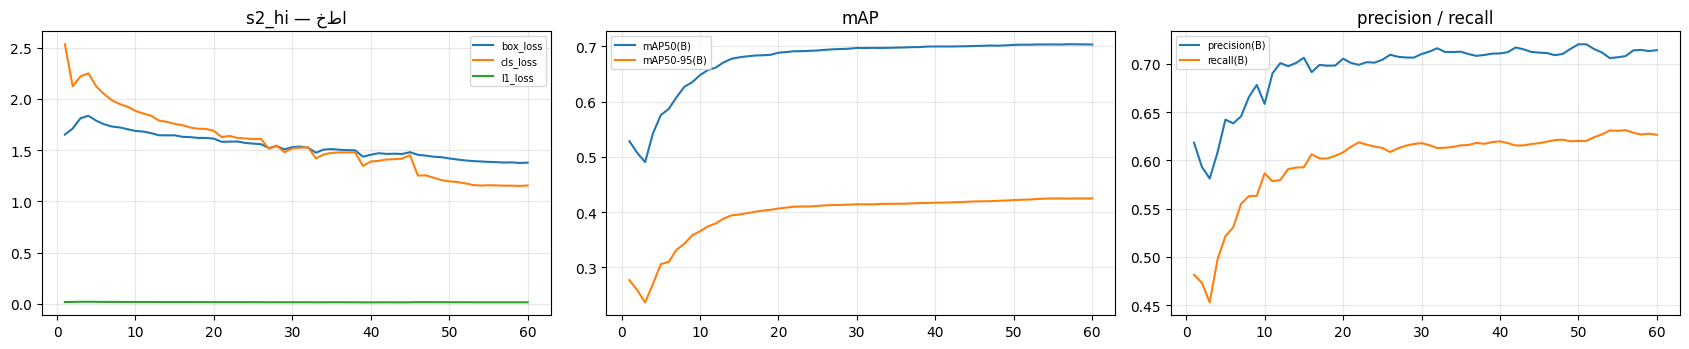

In [ ]:
from ultralytics import YOLO
import pandas as pd, matplotlib.pyplot as plt, os, glob

model = YOLO(BEST)
print('کلاس‌های مدل نهایی:', model.names, '  ← فقط ۲ کلاس ✓\n')
mt = model.val(data=YAML, split='test', imgsz=IMGSZ_HI, conf=0.001, iou=0.6, plots=True)

print('\n' + '='*48)
print(f"{'معیار':24}{'مقدار':>14}")
print('-'*48)
print(f"{'mAP@50':24}{mt.box.map50:>14.4f}")
print(f"{'mAP@50-95':24}{mt.box.map:>14.4f}")
print(f"{'precision':24}{mt.box.mp:>14.4f}")
print(f"{'recall':24}{mt.box.mr:>14.4f}")
print('-'*48)
for i, nm in model.names.items():
    print(f"{'mAP@50 — '+nm:24}{mt.box.ap50[i]:>14.4f}")
print('='*48)
print(f"\nمدل خام YOLO26 روی این مسئله: 0.0000  (کلاس fire/smoke نداشت)")

for name in [s[0] for s in stages]:
    csv = f'{DRIVE_RUN}/{name}/results.csv'
    if not os.path.exists(csv): continue
    df = pd.read_csv(csv); df.columns = df.columns.str.strip()
    fig, ax = plt.subplots(1, 3, figsize=(17, 3.6))
    for c in [c for c in df.columns if 'train/' in c and 'loss' in c]:
        ax[0].plot(df['epoch'], df[c], label=c.split('/')[-1])
    ax[0].set_title(f'{name} — خطا'); ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)
    for c in ['metrics/mAP50(B)','metrics/mAP50-95(B)']:
        if c in df: ax[1].plot(df['epoch'], df[c], label=c.split('/')[-1])
    ax[1].set_title('mAP'); ax[1].legend(fontsize=7); ax[1].grid(alpha=.3)
    for c in ['metrics/precision(B)','metrics/recall(B)']:
        if c in df: ax[2].plot(df['epoch'], df[c], label=c.split('/')[-1])
    ax[2].set_title('precision / recall'); ax[2].legend(fontsize=7); ax[2].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 12 · ★ Choosing the operating point based on **false alarms**

This is where an academic model turns into a product.

Ultralytics picks `best.pt` based on **fitness**. But the customer isn't buying mAP —
they're asking:

> "How many times a night does it false-alarm?"

So we tune the threshold on **negative images**: the highest recall while the false
alarm rate stays under the cap.

آزمون: 2,271 مثبت · 3,355 منفی

   آستانه     آلارم کاذب       تشخیص
--------------------------------------
     0.10          2.30%       99.0%
     0.15          1.55%       98.9%
     0.20          1.25%       98.5%
     0.25          1.00%       98.3%
     0.30          0.70%       97.9%
     0.40          0.60%       95.2%
     0.50          0.40%       90.6%
     0.60          0.15%       83.7%
     0.70          0.05%       68.8%
     0.80          0.05%       40.7%

★ آستانهٔ پیشنهادی = 0.25  (آلارم کاذب 1.00% · تشخیص 98.3%)


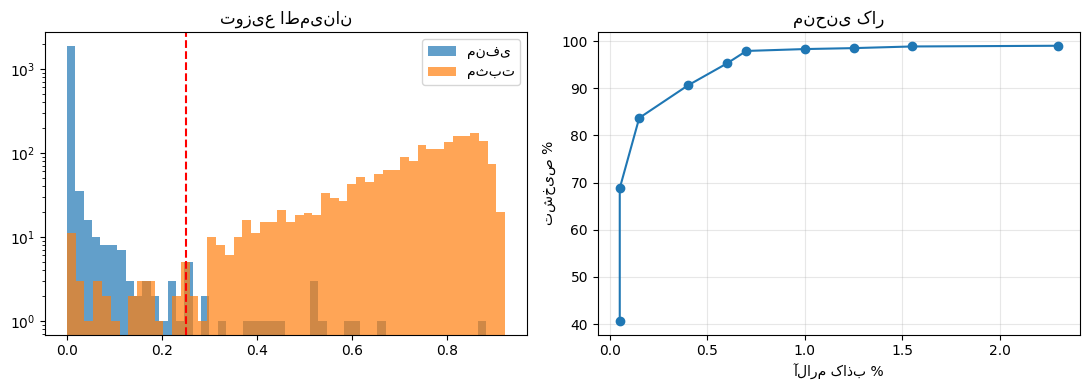

In [ ]:
import glob, os, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO(BEST)
neg, pos = [], []
for ip in glob.glob(f'{DATA_DIR}/images/test/*'):
    lp = f"{DATA_DIR}/labels/test/{os.path.splitext(os.path.basename(ip))[0]}.txt"
    has = os.path.exists(lp) and any(l.strip() for l in open(lp).read().splitlines())
    (pos if has else neg).append(ip)
print(f'آزمون: {len(pos):,} مثبت · {len(neg):,} منفی')

SAMPLE = 2000
def max_conf(paths):
    out = []
    for i in range(0, len(paths), 64):
        for r in model.predict(paths[i:i+64], imgsz=IMGSZ_HI, conf=0.01, verbose=False):
            c = r.boxes.conf
            out.append(float(c.max()) if c is not None and len(c) else 0.0)
    return np.array(out)

cn, cp = max_conf(neg[:SAMPLE]), max_conf(pos[:SAMPLE])
print(f"\n{'آستانه':>9}{'آلارم کاذب':>15}{'تشخیص':>12}")
print('-'*38)
rows = []
for th in [0.10,0.15,0.20,0.25,0.30,0.40,0.50,0.60,0.70,0.80]:
    far, tpr = (cn>=th).mean(), (cp>=th).mean()
    rows.append((th,far,tpr)); print(f'{th:>9.2f}{far*100:>14.2f}%{tpr*100:>11.1f}%')

TARGET_FAR = 0.01
ok = [r for r in rows if r[1] <= TARGET_FAR]
if ok:
    th, far, tpr = min(ok, key=lambda r: r[0])
    print(f'\n★ آستانهٔ پیشنهادی = {th:.2f}  (آلارم کاذب {far*100:.2f}% · تشخیص {tpr*100:.1f}%)')
else:
    th = 0.5; print(f'\n⚠️ هیچ آستانه‌ای به ≤{TARGET_FAR*100:.0f}% نرسید — {th} موقتاً')
RECOMMENDED_CONF = float(th)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.hist(cn, bins=50, alpha=.7, label='منفی'); plt.hist(cp, bins=50, alpha=.7, label='مثبت')
plt.axvline(th, color='r', ls='--'); plt.yscale('log'); plt.legend(); plt.title('توزیع اطمینان')
plt.subplot(1,2,2)
plt.plot([r[1]*100 for r in rows],[r[2]*100 for r in rows],'o-')
plt.xlabel('آلارم کاذب %'); plt.ylabel('تشخیص %'); plt.grid(alpha=.3); plt.title('منحنی کار')
plt.tight_layout(); plt.show()

## 13 · Production export + **real** speed measurement

### An honest answer to "do we also get faster?"

| Speed source | Does it help? |
|---|---|
| **the fine-tune itself** | ❌ **none** — architecture and FLOPs don't change |
| 2-class head instead of 80 | ✅ a little — the detection head gets smaller |
| YOLO26 without NMS | ✅ NMS is on CPU and doesn't batch; removing it makes latency **predictable** |
| lower `imgsz` | ✅ a lot — FLOPs scale with the square of size |
| **TensorRT FP16** | ✅✅ **biggest win** |

**So yes, we do get faster — but through export and deployment, not through training.**
The cell below actually measures all of it.

In [ ]:
import time, torch, os
from ultralytics import YOLO

def bench(m, imgsz, n=40, half=False):
    x = torch.zeros(1,3,imgsz,imgsz)
    for _ in range(8): m.predict(x, imgsz=imgsz, half=half, verbose=False)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t = time.time()
    for _ in range(n): m.predict(x, imgsz=imgsz, half=half, verbose=False)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    return (time.time()-t)/n*1000

tuned = YOLO(BEST)
if 'BASE_MS' not in globals():# section 8 was skipped in resume mode — grab it now
    _b = YOLO(MODEL); BASE_MS = bench(_b, IMGSZ_HI); del _b
rows = [('YOLO26 خام (۸۰ کلاس)', f'{IMGSZ_HI} PyTorch', BASE_MS),
        ('مدل ما (۲ کلاس)',       f'{IMGSZ_HI} PyTorch', bench(tuned, IMGSZ_HI)),
        ('مدل ما — FP16',         f'{IMGSZ_HI} PyTorch', bench(tuned, IMGSZ_HI, half=True)),
        ('مدل ما — imgsz 512',    '512 PyTorch',         bench(tuned, 512)),
        ('مدل ما — imgsz 416',    '416 PyTorch',         bench(tuned, 416))]
for fmt, lbl, kw in [('onnx','onnxruntime',dict(simplify=True)),
                     ('engine','TensorRT',dict(half=True))]:
    try:
        p = tuned.export(format=fmt, imgsz=IMGSZ_HI, **kw)
        rows.append((f'مدل ما — {fmt.upper()}', f'{IMGSZ_HI} {lbl}', bench(YOLO(p), IMGSZ_HI)))
    except Exception as e:
        print(f'⚠️ خروجی {fmt} نگرفت: {str(e)[:120]}')

print('\n' + '='*76)
print(f"{'حالت':34}{'اجرا':22}{'ms':>9}{'FPS':>10}")
print('-'*76)
for nm, mode, ms in rows: print(f'{nm:34}{mode:22}{ms:>9.1f}{1000/ms:>10.1f}')
print('='*76)
print('\nیادآوری: fine-tune سرعت را عوض نمی‌کند — خروجی و اندازهٔ ورودی عوض می‌کنند.')

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

2026-09-10 16:12:59,466 - [modelopt][onnx] - INFO - Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


INFO:modelopt.onnx:Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


2026-09-10 16:12:59,812 - [modelopt][onnx] - INFO - Running ONNX Runtime to obtain reference outputs (this may take a while)...


INFO:modelopt.onnx.autocast:Running ONNX Runtime to obtain reference outputs (this may take a while)...


...

2026-09-10 16:13:01,822 - [modelopt][onnx] - WARNING - Did not find  in value info map! Assuming not castable


2026-09-10 16:13:01,955 - [modelopt][onnx] - WARNING - Some initializers contain values smaller than smallest fp16 value, values will be replaced with 6.0e-08.


2026-09-10 16:13:04,294 - [modelopt][onnx] - INFO - Converted 366/368 nodes (99.46%) to fp16


INFO:modelopt.onnx.autocast:Converted 366/368 nodes (99.46%) to fp16


TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 6, 8400) DataType.FLOAT
TensorRT: building FP16 engine as /content/runs/fireguard_s_v4_s2_hi/weights/best.engine
TensorRT: export success ✅ 446.4s, saved as '/content/runs/fireguard_s_v4_s2_hi/weights/best.engine' (94.7 MB)

Export complete (446.6s)
Results saved to /content/runs/fireguard_s_v4_s2_hi/weights/best.engine
Predict:         yolo predict task=detect model=/content/runs/fireguard_s_v4_s2_hi/weights/best.engine imgsz=640 quantize=16
Validate:        yolo val task=detect model=/content/runs/fireguard_s_v4_s2_hi/weights/best.engine imgsz=640 data=/content/fireguard_data/fire.yaml quantize=16 
Visualize:       https://netron.app
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Loading /content/runs/fireguard_s_v4_s2_hi/weights/best.engine for TensorRT inference...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. U

## 14 · Save to Drive + model card

In [ ]:
import shutil, os, glob, json

FINAL = f'{DRIVE_RUN}/final'
os.makedirs(FINAL, exist_ok=True)
shutil.copy(BEST, f'{FINAL}/best.pt')
for pat in ['*.onnx','*.engine','*.torchscript']:
    for f in glob.glob(os.path.join(os.path.dirname(BEST), pat)):
        shutil.copy(f, f'{FINAL}/{os.path.basename(f)}')

card = {
    'run': RUN, 'base_model': MODEL,
    'classes': {0:'fire', 1:'smoke'},
    'train': {'epochs': EPOCHS, 'progressive': PROGRESSIVE,
              'imgsz': [IMGSZ_LO, IMGSZ_HI] if PROGRESSIVE else [IMGSZ_HI],
              'cctv_aug': bool(CCTV_AUGS)},
    'metrics': {'mAP50': float(mt.box.map50), 'mAP50_95': float(mt.box.map),
                'mAP50_fire': float(mt.box.ap50[0]), 'mAP50_smoke': float(mt.box.ap50[1]),
                'precision': float(mt.box.mp), 'recall': float(mt.box.mr)},
    'recommended_conf': RECOMMENDED_CONF,
    'latency_ms': {nm: round(ms,2) for nm,_,ms in rows},
    'data': {'source': 'FASDD_CV (CC BY 4.0) + D-Fire',
             'traps_handled': ['کلاس برعکس D-Fire', 'تقسیم گروه‌آگاه',
                               'هم‌رویداد ۴..۱۲ بیت', 'سطل هش غول‌پیکر',
                               'سقف imgsz=640', 'resume درون‌مرحله‌ای']},
}
json.dump(card, open(f'{FINAL}/model_card.json','w'), indent=2, ensure_ascii=False)

print('✅ ذخیره شد:')
print(f'   وزن     : {FINAL}/best.pt')
print(f'   خروجی‌ها: {FINAL}/')
print(f'   شناسنامه: {FINAL}/model_card.json\n')
print(json.dumps(card, indent=2, ensure_ascii=False))

✅ ذخیره شد:
   وزن     : /content/drive/MyDrive/FireGuard_Runs/fireguard_s_v4/final/best.pt
   خروجی‌ها: /content/drive/MyDrive/FireGuard_Runs/fireguard_s_v4/final/
   شناسنامه: /content/drive/MyDrive/FireGuard_Runs/fireguard_s_v4/final/model_card.json

{
  "run": "fireguard_s_v4",
  "base_model": "yolo26s.pt",
  "classes": {
    "0": "fire",
    "1": "smoke"
  },
  "train": {
    "epochs": 60,
    "progressive": false,
    "imgsz": [
      640
    ],
    "cctv_aug": true
  },
  "metrics": {
    "mAP50": 0.7168151954831234,
    "mAP50_95": 0.4278524427628218,
    "mAP50_fire": 0.725772806202469,
    "mAP50_smoke": 0.7078575847637778,
    "precision": 0.7475360968034711,
    "recall": 0.6247792580562648
  },
  "recommended_conf": 0.25,
  "latency_ms": {
    "YOLO26 خام (۸۰ کلاس)": 16.06,
    "مدل ما (۲ کلاس)": 16.12,
    "مدل ما — FP16": 18.57,
    "مدل ما — imgsz 512": 15.21,
    "مدل ما — imgsz 416": 14.72,
    "مدل ما — ENGINE": 12.02
  },
  "data": {
    "source": "FASDD_CV (CC BY 4

---

## Usage

```python
from ultralytics import YOLO
m = YOLO('/content/drive/MyDrive/FireGuard_Runs/<RUN>/final/best.pt')
r = m.predict(frame, conf=<recommended_conf from the model card>)
```

## The highest-value next step

Record ~12 hours of raw footage from your actual camera (**unlabeled**) and run
section 12 on it. Then, for the first time, you'll have a real number for "how many
false alarms a night" — the number the customer is actually buying.

After that: **BLAZE** — tracking + DFT flicker verifier + smoke-column growth, per `PLAN_V2.md`.